# Sentimental Analysis 


### By Ritesh Noukudkar

In [2]:
import pandas as pd
import numpy as np
import nltk

In [3]:
df= pd.read_csv('../data/IMDBdata.csv')

In [11]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## DataSet Size in How much row and coulumn 

In [13]:
df.shape

(50000, 2)

### Dataset Information 

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


### Check Null Values 

In [15]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

### Check duplicated 

In [16]:
df.duplicated().sum()

np.int64(418)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All Libraries Imported Successfully ✅")

All Libraries Imported Successfully ✅


### download NLTK Resources 

In [5]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
df=pd.read_csv('../data/IMDBdata.csv')

In [16]:
df['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

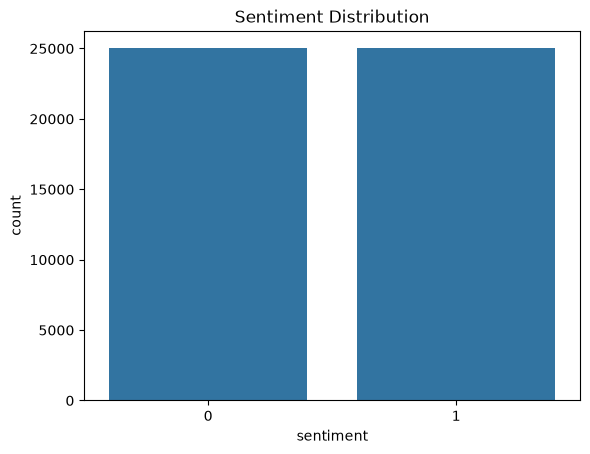

In [32]:
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.savefig("../images/sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Import Stopwords

In [15]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

### Text Cleaning Function 

In [13]:
import re 
import string 

def clean_text(text):
    # Lowercase the text
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    text =re.sub(r'<.*?>', '', text)  
    # Remove HTML tags
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text =text.translate(str.maketrans('', '', string.punctuation))

    text=text.strip()
    return text

### Aplly Cleaning 

In [17]:
df['cleaned_review'] = df['review'].apply(clean_text)

### Remove Stopwords

In [18]:
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(words)

df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords)

### compare before & After 

In [19]:
print("Original Review:\n")
print(df['review'][0]) 

print("\n" + "="*100 + "\n")

print("\nCleaned Review:\n")
print(df['cleaned_review'][0])

Original Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

### Convert Sentiment To Numbers    

In [9]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1, 
    'negative': 0
    })                               

In [14]:
df.head()

,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,1,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love time money visually stunni...


## TF-IDF Vectorization 

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_review'])

y = df['sentiment']

print("Shape of Features:", X.shape)

Shape of Features: (50000, 5000)


In [8]:
print(df.columns)

Index(['review', 'sentiment'], dtype='str')


### Train Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (40000, 5000)
Testing Data  : (10000, 5000)


### Train Logistic Regression Model 

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("✅ Model Training Completed")

✅ Model Training Completed


### Prediction 

In [26]:
y_pred = model.predict(X_test)

### Accuracy 

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 88.64%


### Classification Report

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### confusion Matrix 

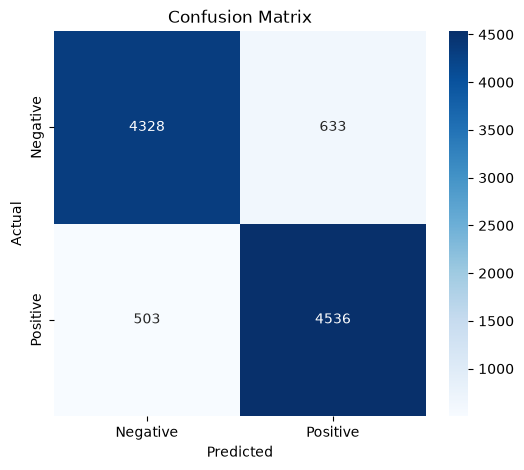

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("../images/confusion_matrix.png", dpi=300, bbox_inches="tight")
 
plt.show()

# Conclusion

This Sentiment Analysis project successfully classified movie reviews as Positive or Negative using Natural Language Processing (NLP) and Machine Learning techniques.

The dataset was preprocessed through text cleaning, stopword removal, and TF-IDF vectorization to transform textual data into numerical features. A Logistic Regression model was trained on the processed data and achieved effective sentiment classification performance.

The project demonstrates the complete workflow of a machine learning solution, including data preprocessing, feature engineering, model training, evaluation, and prediction. It highlights how NLP can be used to extract meaningful insights from textual data and support data-driven decision-making.

This project provides a strong foundation for advanced text analytics and can be further enhanced using deep learning models such as LSTM, GRU, or BERT for improved accuracy.